# IN1160 – Oblig 1b: Klassifisering

**Våren 2026**

Det er en god idé å lese gjennom hele oppgavesettet før dere setter i gang.
Dersom dere har spørsmål så kan dere:

- gå i gruppetime,
- spørre på Discourse
- eller sende epost til in1160-hjelp@ifi.uio.no dersom alternativene over av en eller annen grunn ikke passer for spørsmålet.


## Innlevering

Oppgaven leveres innen 25.02. klokken 23.59 i [Devilry](https://devilry.ifi.uio.no/).

Innleveringen skal bestå av én Jupyter notebook med både kode og tilhørende forklaringer. **Før innlevering skal du kjøre gjennom hele notebooken, før du lagrer siste gang. Den bør kjøre uten å feile og vise den grafikken og de utskriftene som skal være med.**

Vi understreker at innlevering av kode alene ikke er nok for å bestå oppgaven – vi forventer at notebooken også skal inneholde kommentarer (på norsk eller engelsk) på hva dere har gjort og begrunnelser for valgene dere har tatt underveis.
La enhver oblig bli en trening i å formidle forskning. Bruk helst hele setninger, og matematiske formler om nødvendig. Resultater skal presenteres i tabeller på en oversiktlig måte.
Det å forklare med egne ord, bruke begreper vi har gått gjennom på forelesningene og å forklare og reflektere over løsningene deres er en viktig del av læringsprosessen – ta det på alvor!

Når det gjelder bruk av generative prateroboter (ChatGPT og lignende): Dere kan bruke dem som en "sparringspartner", for eksempel for å forklare noe dere ikke helt har forstått. Dere har imidlertid ikke lov til å bruke dem til å generere løsninger (enten delvis eller fullstendig) til noen av oppgavene. Funksjoner for automatisk skriving av kode, som Copilot i VS Code, må derfor også være deaktivert mens dere jobber på obligen.  
Bruker dere KI-verktøy vil vi også at dere kort beskriver hvordan dere har brukt dem under arbeidet med oppgaven.

Det er ikke mulighet for omlevering av obliger som ikke bestås.


## Bakgrunn

I oblig 1a lagde dere vektorer for ord. Disse baserte seg på hvilke andre ord vi fant i setningen til ordet. Vi så videre at vi kan bruke cosinuslikhet til beregne hvor like to ordvektorer er. 
I denne obligen skal vi benytte oss av lignende metoder, men løfte blikket fra setningsnivå til dokumentnivå for å gjøre dokumentklassifisering.

Vi skal jobbe med datasettet Norwegian Review Corpus (NoReC) som består av anmeldelser hentet fra en rekke norske nettaviser.
Dette datasettet består av over 43 000 dokumenter blant annet tagget med hvilket tema dokumentet diskuterer, som f.eks. musikk, film og TV, spill og restauranter.

En full rad av NoReC er tagget slik:

| id | split | rating | category | day | month | year | excerpt | language | source | authors | title | url | text |
|--------|-------|---|-------|---|---|------|----|----|--------|--------------|---------|------------|---------|
| 001160 | train | 4 | music | 3 | 7 | 2009 | nb | p3 | Andreas Øverland | Ikke helt rett West | https://p3.no/musikk/kategori/anmeldelser/ikke-helt-rett-west | Ikke helt rett West | Kanye West, Roskilde ... |


Mer info finner dere sammen med datasettet [her](https://huggingface.co/datasets/ltg/norec_document).


## Oppgave 1 – Forberede data

I denne oppgaven skal dere laste inn NoReC-datasettet, for å så dele det inn i splitter til trening, validering og testing. 
For å hente hente NoReC-datasettet bruker dere funksjonen `load_dataset()`, som vist her:

In [1]:
from datasets import load_dataset

dataset = load_dataset("ltg/norec")

c:\Users\af64\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### Oppgave 1.1 – Oppdeling av datasett (3 poeng)

Dere skal nå hente ut ønsket data fra datasettet. Dette skal dere gjøre med funksjonen `prepare_data()`.
Denne funksjonen tar inn datasettet og en spesifisert splitt som argumenter og skal returnere to lister: en liste med dokumenttekster og en liste med den respektive kategorien for hvert av dokumentene.
Det er viktig at disse følger hverandre – altså at kategorien for teksten på indeks $i$ i dokumentlista finnes på indeks $i$ i kategorilista. Listene skal derfor også ha samme lengde.

Datasettet er strukturert som en ordbok. For hver av nøklene 'train', 'validation' og 'test' vil dere finne en ny ordbok som blant annet har nøklene 'category' og 'text'.

For å begrense omfanget av dataene vår skal vi begrense oss til kategoriene 'games', 'restaurants' og 'literature'. Tekster og tagger fra alle andre kategorier skal dere altså ikke ta med videre.

Skriv ferdig funksjonen `prepare_data()`.


In [2]:
# Oppgave 1.1
def prepare_data(dataset, split):
    """Henter ønsket data fra datasettet.

    Argumenter:
    - dataset : NoReC-datasettet.
    - split   : En streng som spesifiserer hvilken splitt vi ønsker.

    Returnerer:
    - data   : En liste over dokument-tekstene fra spesifisert splitt.
    - labels : En liste over hvilken kategori dokumentet tilhører.

    De returnerte listene skal være like lange og ha samme rekkefølge.
    For dokumentet på data[i] skal vi altså kunne finne det tilhørende
    kategori i labels[i].
    """

    # Din kode her
    data = dataset[split]["text"]
    labels = dataset[split]["category"]
    
    return data, labels

In [3]:
# Etter å ha implementert `prepare_data()` skal dere kunne dele opp dataene slik:
# Treningsdata
train_data, train_labels = prepare_data(dataset, "train")

# Valideringsdata
dev_data, dev_labels = prepare_data(dataset, "validation")

# Testdata
test_data, test_labels = prepare_data(dataset, "test")

### Oppgave 1.2 – Analyse av splitter (2 poeng)

Nå som dere har delt opp datasettet i de ulike splittene, skal dere gjøre en enkel analyse av disse.
Dere skal her telle opp hvor mange dokumenter det er i hver av de tre splittene og regne ut fordelingen av de ulike kategoriene i hver av splittene.

Presenter resultatene i en markdown-tabell som viser antall dokumenter og prosentvis fordeling av de ulike kategoriene i hver av splittene.
Skriv en kort kommentar om hva dere observerer.

In [4]:
# Oppgave 1.2
#Teller antall documenter i hver splitt
print("Antall treningsdokumenter: " + str(len(train_data)))
print("Antall evalueringsdokumenter: " + str(len(dev_data)))
print("Antall testingsdokumenter: " + str(len(test_data)))

#Får de mulige kategoriene
labels = []
for label in train_labels:
    if label not in labels:
        labels.append(label)

#Ordbøker for å telle antall kategorier
train_label_counts = {}
dev_label_counts = {}
test_label_counts = {}

for label in labels:
    train_label_counts[label] = 0
    dev_label_counts[label] = 0
    test_label_counts[label] = 0

#Set the dictionaries in a list for more concise code
counts = [train_label_counts, dev_label_counts, test_label_counts]
labels2 = [train_labels, dev_labels, test_labels]

for label in labels:
    for i, dictionary in enumerate(counts):
        count = 0
        for label2 in labels2[i]:
            if label2 == label:
                count += 1
        dictionary[label] = count

Antall treningsdokumenter: 34749
Antall evalueringsdokumenter: 4348
Antall testingsdokumenter: 4340


In [5]:
import pandas as pd
label_table = pd.DataFrame({"Training" : counts[0], "Evaluation" : counts[1], "Testing" : counts[2]})
print(label_table)

ratio_df = label_table
for label in label_table:
    ratio_df[label] = ratio_df[label]/ratio_df[label].sum()

print(ratio_df)

             Training  Evaluation  Testing
screen          12536        1569     1579
games            1453         179      180
music           11777        1445     1444
stage             856         132      107
literature       4337         539      547
misc              156          28       24
products         2771         347      345
restaurants       745          94       98
sports            118          15       16
             Training  Evaluation   Testing
screen       0.360759    0.360856  0.363825
games        0.041814    0.041168  0.041475
music        0.338916    0.332337  0.332719
stage        0.024634    0.030359  0.024654
literature   0.124809    0.123965  0.126037
misc         0.004489    0.006440  0.005530
products     0.079743    0.079807  0.079493
restaurants  0.021439    0.021619  0.022581
sports       0.003396    0.003450  0.003687


#### Oppgave 1.2 – Tekstbesvarelse

_Legg inn tabellen din her. Hva ser du av resultatene?_


**Svar:** Man ser at det er klart flest artikler som handler om film, TV og musikk, mens det er færrest
om restauranter, sport, og andre. Hvert av de tre settene har en lignende distribusjon av artikler, som kan ses
av den andre tabellen som viser forholde mellom en artikkeltype og totalt antall artikler.

## Oppgave 2

I oblig 1a lagde dere en egen klasse som lagde ordvektorer. I denne oppgaven skal dere benytte dere av scikit-learn sin `CountVectorizer`. Denne fungerer stort sett på samme måte som den klassen dere lagde i oblig 1a, men den gjør blant annet tokenisering på egenhånd. Dere kan altså sende inn dokumentene som sammenhengende strenger i stedet for som lister av tokens. Klassen har også nyttige parametere som kan hjelpe oss med å begrense vokabularet vårt, slik vi gjorde manuelt i 1a.

`CountVectorizer` importeres i cellen under.

In [6]:
from sklearn.feature_extraction.text import CountVectorizer

### Oppgave 2.1 – Vektorisering (3 poeng)

Dere skal her bruke `CountVectorizer` til å lage vektorer av dokumentene. 
Her må dere først initialisere klassen med parameteren `max_features` satt til 5000, slik at vi bare bruker de mest frekvente ordene. I denne obligen bryr vi oss ikke med å fjerne stoppord, selv om det er mulig gjennom parameteren `stop_words`.

Dere må så bruke metoden `.fit()` for å identifisere vokabularet modellen skal bruke. Her sender dere inn treningssettet som parameter. 

Etter dette kan dere bruke vektorisereren med `.transform()`, der dere sender inn hver datasplitt. Dere skal da få returnert en liste med vektoriserte versjoner av dokumentene. Lista har samme rekkefølge som dokumentene dere sendte inn.


In [7]:
# Oppgave 2.1
vectorizer = CountVectorizer(max_features=5000)
X = vectorizer.fit(train_data, y = train_labels)

In [8]:
train_vector = vectorizer.transform(train_data)
dev_vector = vectorizer.transform(dev_data)
test_vector = vectorizer.transform(test_data)

### Oppgave 2.2 – Visualisering (2 poeng)

Vi har nå vektorrepresentasjoner av dataene. Disse vektorene kan plasseres i et _vektorrom_, som så vi kan visualisere.
Å visualisere dataene kan hjelpe oss med å forstå sammenhenger mellom dataene.
Vi har laget en ferdig funksjon `scatter_plot()` som dere kan bruke.
Denne tar to argumenter:
 - `vectors` – De vektoriserte dokumentene
 - `labels`  – Den tilhørende lista med kategorier

Bruk funksjonen `scatter_plot()` til å visualisere dokumentvektorene for treningssettet. Beskriv og diskuter hva du ser.


In [9]:
import matplotlib.pyplot as plt
from sklearn.decomposition import TruncatedSVD

def scatter_plot(vectors, labels):
    """
    Gir en 2D-visualisering av vektorrommet.

    Argumenter:
    - vectors : Vektoriserte data.
    - labels  : De tilhørende taggene.

    Legg merke til at vi her går fra 5000 dimensjoner (antall trekk)
    til kun 2 (x-aksen og y-aksen). Dette gjøres ved å bruke
    Singular Value Decomposition (SVD). Dette er ikke pensum, men
    kort fortalt er det en teknikk for dimensjonsreduksjon som
    bevarer mest mulig informasjon fra de opprinnelige vektorene.
    """
    svd = TruncatedSVD(2).fit_transform(vectors)
    x_axis, y_axis = svd[:, 0], svd[:, 1]

    unique_labels = list(set(labels))
    label_to_int = {label: i for i, label in enumerate(unique_labels)}
    numeric_labels = [label_to_int[l] for l in labels]

    plt.figure(figsize=(8, 6))
    color_map = plt.cm.get_cmap("jet", len(set(labels)))
    scatter = plt.scatter(x_axis, y_axis, c=numeric_labels, cmap=color_map)
    handles, _ = scatter.legend_elements(prop="colors")
    plt.legend(handles, unique_labels, title="Labels")
    plt.show()


C:\Users\af64\AppData\Local\Temp\ipykernel_26368\3595697190.py:26: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  color_map = plt.cm.get_cmap("jet", len(set(labels)))


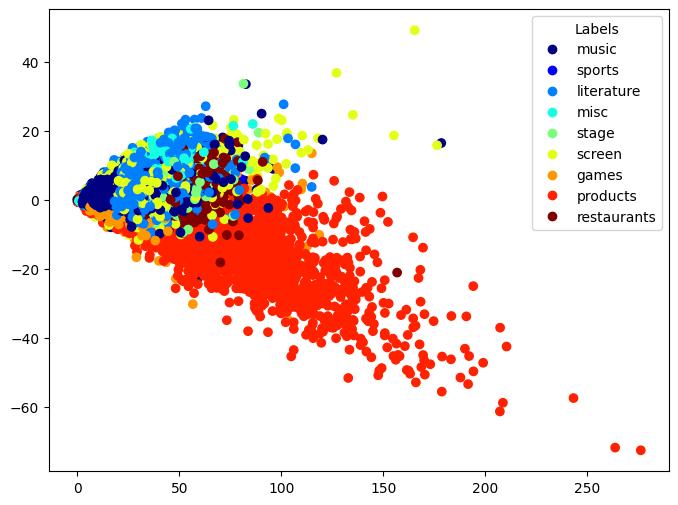

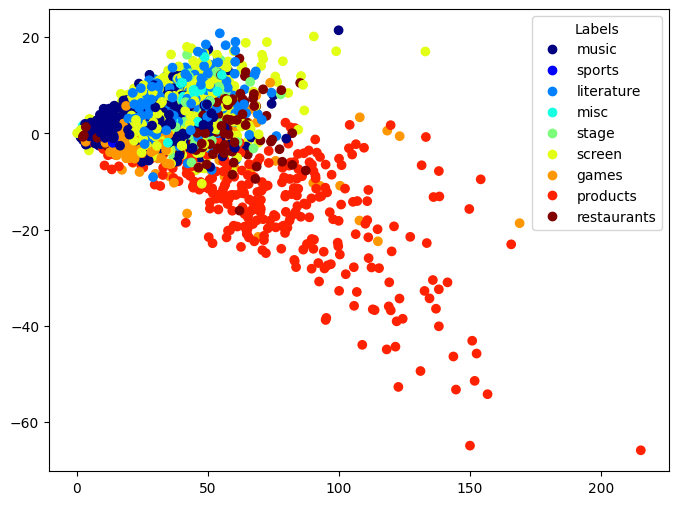

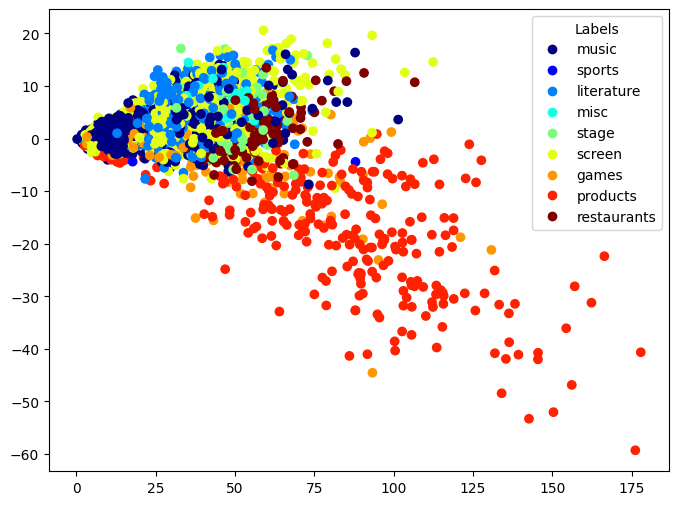

In [10]:
# Oppgave 2.2
scatter_plot(train_vector, train_labels)
scatter_plot(dev_vector, dev_labels)
scatter_plot(test_vector, test_labels)

#### Oppgave 2.2 – Tekstbesvarelse
*Hva ser du på plottene?* 

**Svar:** Man får et scatter-plot der hvert punkt representerer en artikkel, og hvilken farge den er representerer en viss kategori. Fra plottene ser man klart at det er en distribusjon blant dem, da forskjellige kategorier dominerer forskjellige områder.

### Oppgave 2.3 – Vekting (3 poeng)

For å få bedre representasjoner kan det være lurt å vekte de ulike dimensjonene/trekkene ulikt, slik at de trekkene som er mer informative gis høyere vekt. Her skal dere bruke en type vekting kalt _term frequency–inverse document frequency (TF-IDF)_.

Scikit-learn har en innebygd klasse for TF-IDF kalt `TfidfTransformer` som dere skal bruke. Den tar dokumentvektorer fra `CountVectorizer` som input og gir ut nye, vektede vektorer som output.
I likhet med `CountVectorizer` må denne tilpasses treningssettet med `.fit()` før vi kan ta den i bruk. Dette er for å få gjort de nødvendige frekvenstellingene i dokumentene.

I denne oppgaven skal dere:

- Lage en TF-IDF-vektet representasjon av dokumentene
- Visualisere de vektede vektorene med `scatter_plot()`. Ser dere noen forskjell på resultatet sammenlignet med det dere fikk uten TF-IDF-vekting?


In [11]:
from sklearn.feature_extraction.text import TfidfTransformer

C:\Users\af64\AppData\Local\Temp\ipykernel_26368\3595697190.py:26: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  color_map = plt.cm.get_cmap("jet", len(set(labels)))


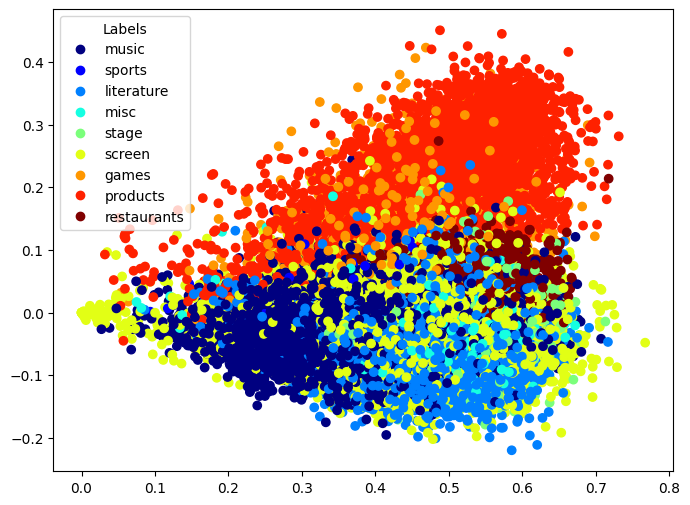

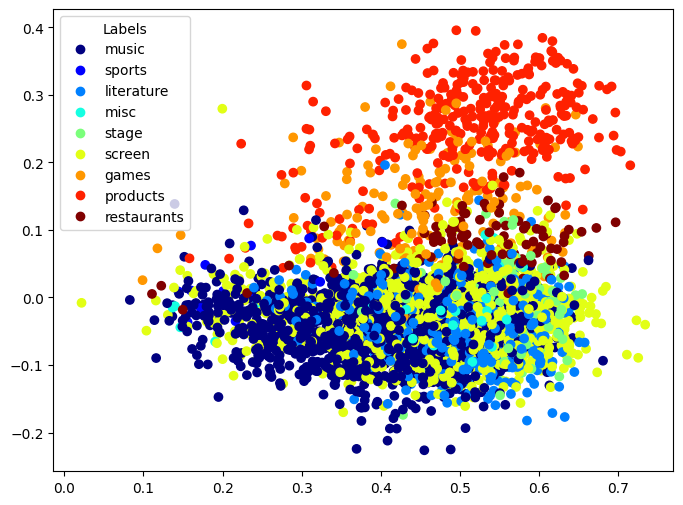

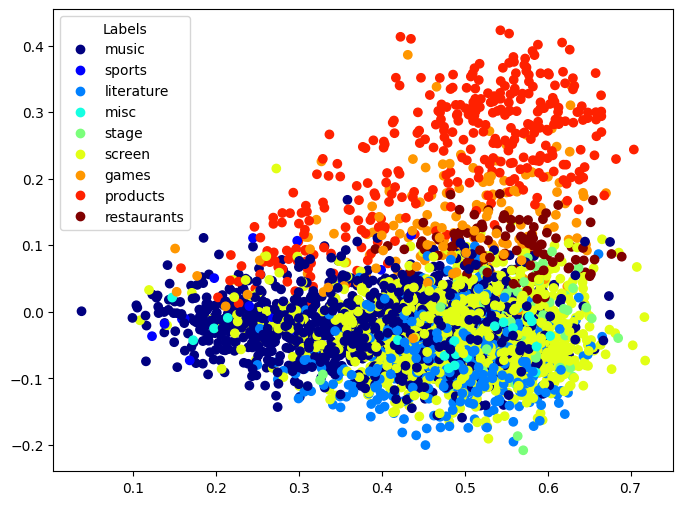

In [12]:
# Oppgave 2.3
transformer = TfidfTransformer()
transformer.fit(train_vector)
transformed_train_vector = transformer.transform(train_vector)
transformed_dev_vector = transformer.transform(dev_vector)
transformed_test_vector = transformer.transform(test_vector)

scatter_plot(transformed_train_vector, train_labels)
scatter_plot(transformed_dev_vector, dev_labels)
scatter_plot(transformed_test_vector, test_labels)

#### Oppgave 2.3 – Tekstbesvarelse
*Ser du noen forskjell mellom vektorene med og uten tf-idf?* 

**Svar:** Den mest nyttige forskjellen er at punktene er distribuert over et større område, som gir klarere hvilke områder en kategori tilhører. Dette vil være nyttig for klassifikasjon, da det er mindre sjanse for at en artikkel blir kategorisert feil.

## Oppgave 3 – Klassifisering med *k*-NN

Nå er vi klare for å lage en klassifikator. Klassifikatoren skal la oss predikere hvilken kategori et gitt dokument tilhører.
For å gjøre dette skal vi bruke `KNeighborsClassifier` fra scikit-learn som baserer seg på _k_-NN-algoritmen.

Klassifikatoren trenes med `.fit()`, der vi sender inn treningsdataene. Etter dette kan vi predikere med `.predict()` på validerings- og testdata.  
For best resultat er det viktig at dataene vi trener med og de vi ønsker å predikere, er preprosessert på samme måte. For eksempel vil en klassifikator trent på data uten TF-IDF-vekting gi dårlige resultater for dokumentvektorer med TF-IDF.


For å måle hvor godt klassifikatoren klarer å klassifisere de ulike dokumentene kan vi bruke _nøyaktighet_ (engelsk: _accuracy_), som regnes ut basert på hvor mange vi klarte å predikere korrekt, delt på antall vi forsøkte å predikere totalt.

For å regne ut dette kan dere bruke funksjonen `accuracy_score()` fra scikit-learn, som tar inn to lister: først en liste de korrekte merkelappene til dataene, så en liste med merkelapper som klassifikatoren har predikert.

Alternativt kan vi bruke $F_{1}$-_mål_ (engelsk: $F_{1}$-_score_), som er et gjennomsnitt mellom _presisjon_ (engelsk: _precision_) og _sensitivitet_ (engelsk: _recall_). Dette kan vi regne ut ved å bruke `f1_score()` fra scikit-learn.  
Denne tar også inn de to listene som parametere, men siden vi her jobber med flere klasser, må vi endre parameteren `average` som spesifiserer hvordan snittet mellom klassene skal regnes ut. Her kan den settes til `'macro'`.


In [13]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score

### Oppgave 3.1 – _k_-NN (3 poeng)

Lag en instans av `KNeighborsClassifier` der k = 1. Tren denne på treningsdataene (med TF-IDF-vekting) og gjør prediksjoner på valideringsdataene. Vis resultatene for både `accuracy_score()` og `f1_score()`. Gjør så det samme med en instans der k = 5000. 

Rapporter resultatene i en markdown-celle, der dere også skriver kort om hvordan disse resultatene kan knyttes til over- og undertilpasning.

In [14]:
# Oppgave 3.1
classifier = KNeighborsClassifier(n_neighbors=1)
classifier.fit(X=transformed_train_vector, y=train_labels)
predictions = classifier.predict(X=transformed_dev_vector)
print("Nøyaktighet for k = 1: " + str(round(accuracy_score(dev_labels, predictions), 3)))
print("F1-mål for k = 1: " + str(round(f1_score(dev_labels, predictions, average="macro"), 3)))

classifier = KNeighborsClassifier(n_neighbors=5000)
classifier.fit(X=transformed_train_vector, y=train_labels)
predictions = classifier.predict(X=transformed_dev_vector)
print("Nøyaktighet for k = 5000: " + str(round(accuracy_score(dev_labels, predictions), 3)))
print("F1-mål for k = 5000: " + str(round(f1_score(dev_labels, predictions, average="macro"), 3)))

Nøyaktighet for k = 1: 0.519
F1-mål for k = 1: 0.431
Nøyaktighet for k = 5000: 0.602
F1-mål for k = 5000: 0.246


#### Oppgave 3.1 – Tekstbesvarelse

_Rapporter resultatene og knytt de opp mot over- og undertilpasning._

For k = 1 fikk vi en nøyaktighet på 0.519 og F1-mål på 0.431. For k = 5000 ble nøyaktigheten 0.602 og F1-målet 0.246. k = 1 ga lav nøyaktighet of F1-mål, som er forventet gitt at kun en nabo kan lett føre til undertilpasning. k = 5000 ga høyere nøyaktighet, men langt lavere F1-mål, som sier ganske klart at k = 5000 fører til overtilpasning.

### Oppgave 3.2 – Hyperparametertilpassing (5 poeng)

I _k_-NN er _k_ en hyperparameter. Ved å endre på verdien av _k_ vil vi få ulike resultater fra klassifikatoren.
Hvilken _k_-verdi som passer best er avhengig av datasett, preprosessering og vekting. Vi må derfor bare prøve oss fram til vi finner passende verdier.

I denne oppgaven skal vi prøve en rekke _k_-verdier for å se hva som gir best resultat.

Når dere skal finne den beste _k_-verdien, skal dere bruke valideringssettet.

Lag ei løkke som trener en _k_-NN-klassifikator for forskjellige verdier av _k_ fra 1 til 20.
For hver _k_-verdi skal dere teste både dataene med TF-IDF-vekting og dataene uten, og beregne enten nøyaktighet eller $F_1$-mål for hver av dem. Hvilket av målene dere bruker velger dere selv, men dere må skrive minst to setninger om hvilke fordeler og ulemper de to målene har. 

Lag en tabell der dere inkluderer resultatene deres og beskriv kort hva dere observerer.


In [15]:
# Oppgave 3.2

hyperparameter_table = {"Vekted, Nøyaktighet" : [], "Vekted, F1-mål" : [], "Ikke vekted, Nøyaktighet" : [], "Ikke vekted, F1-mål" : []}

for k in range(1, 21):
    classifier = KNeighborsClassifier(n_neighbors=k)
    classifier.fit(X=transformed_train_vector, y=train_labels)
    predictions = classifier.predict(X=transformed_dev_vector)
    hyperparameter_table["Vekted, Nøyaktighet"].append(accuracy_score(dev_labels, predictions))
    hyperparameter_table["Vekted, F1-mål"].append(f1_score(dev_labels, predictions, average="macro"))

    classifier = KNeighborsClassifier(n_neighbors=k)
    classifier.fit(X=train_vector, y=train_labels)
    predictions = classifier.predict(X=dev_vector)
    hyperparameter_table["Ikke vekted, Nøyaktighet"].append(accuracy_score(dev_labels, predictions))
    hyperparameter_table["Ikke vekted, F1-mål"].append(f1_score(dev_labels, predictions, average="macro"))
    

In [16]:
row_names = {}
for i in range(20):
    row_names[i] = i+1
hyperparameter_df = pd.DataFrame(hyperparameter_table)
hyperparameter_df = hyperparameter_df.rename(index = row_names)
print(hyperparameter_df)
print(hyperparameter_df.idxmax())


    Vekted, Nøyaktighet  Vekted, F1-mål  Ikke vekted, Nøyaktighet  \
1              0.518629        0.431478                  0.645584   
2              0.517939        0.419375                  0.633395   
3              0.500460        0.387449                  0.663293   
4              0.500690        0.391040                  0.698482   
5              0.489650        0.375483                  0.703772   
6              0.489650        0.369069                  0.715271   
7              0.483211        0.353700                  0.718951   
8              0.673643        0.530312                  0.720331   
9              0.689742        0.618537                  0.722631   
10             0.741720        0.656331                  0.729531   
11             0.748620        0.670896                  0.730681   
12             0.767479        0.688289                  0.735511   
13             0.770929        0.687566                  0.727691   
14             0.780819        0.7

In [17]:
#Siste kolonne av tabellen ble trunkert, så skriver den ut her
print(hyperparameter_df["Ikke vekted, F1-mål"])

1     0.505281
2     0.486215
3     0.505605
4     0.517985
5     0.523705
6     0.524205
7     0.535312
8     0.528261
9     0.527816
10    0.528528
11    0.521821
12    0.526338
13    0.520704
14    0.520483
15    0.521480
16    0.519844
17    0.515926
18    0.514540
19    0.505347
20    0.502977
Name: Ikke vekted, F1-mål, dtype: float64


#### Oppgave 3.2 – Tekstbesvarelse

_Inkluder en tabell og diskuter resultatene. Hva er styrkene og svakhetene til henholdsvis nøyaktighet og $F_1$-mål?_

**Svar:** Nøyaktighet er nyttig for å måle hvor nøye prediksjonene er, og gir oss en god idé om hvordan hyperparametre påvirker resultatet selv hvis vektorene ikke er vektet. Gir oss derimot ikke mye informasjon angående overilpasning. Til dette er $F_1$-mål nyttigere, men den fungerer ikke like bra på ikke-vektede vektorer.

### Oppgave 3.3 – Testing (4 poeng)

Dere skal nå ha funnet den kombinasjonen av _k_-verdi og representasjon (vektet/ikke-vektet) som oppnår best nøyaktighet på valideringssettet.  
I denne oppgaven skal dere se hvor godt denne verdien fungerer på testsettet. Testsettet skal være data som klassifikatoren ikke har "sett" før, hverken under trening eller under hyperparametertilpassing.

Dere skal nå trene en _k_-NN-klassifikator med den beste kombinasjonen av _k_-verdi og representasjon fra oppgave 3.2. Dere skal så gjøre prediksjoner på valideringssettet. For disse prediksjonene skal dere rapporterte:

- Nøyaktighet
- $F_1$-mål
- Presisjon
  - Gjøres med `precision_score()`. Denne tar samme parametere som `f1_score()`.
- Sensitivitet
  - Gjøres med `recall_score()`. Denne tar samme parametere som `f1_score()`.

Gjør deretter prediksjoner for det testsettet og rapporter de samme metrikkene. Hvordan er ytelsen på testsettet sammenlignet med valideringssettet?


In [20]:
# Oppgave 3.3
classifier = KNeighborsClassifier(n_neighbors=20)
classifier.fit(X=transformed_train_vector, y=train_labels)
dev_predictions = classifier.predict(X=transformed_dev_vector)
print("Nøyaktighet av evaluering: " + str(round(accuracy_score(dev_labels, dev_predictions), 3)))
print("F1-mål av evaluering: " + str(round(f1_score(dev_labels, dev_predictions, average="macro"), 3)))
print("Presisjon av evaluering: " + str(round(precision_score(dev_labels, dev_predictions, average="macro"), 3)))
print("Sensitivitet av evaluering: " + str(round(recall_score(dev_labels, dev_predictions, average="macro"), 3)))

Nøyaktighet av evaluering: 0.806
F1-mål av evaluering: 0.717
Presisjon av evaluering: 0.89
Sensitivitet av evaluering: 0.665


In [21]:
test_predictions = classifier.predict(X=transformed_test_vector)
print("Nøyaktighet av evaluering: " + str(round(accuracy_score(test_labels, test_predictions), 3)))
print("F1-mål av evaluering: " + str(round(f1_score(test_labels, test_predictions, average="macro"), 3)))
print("Presisjon av evaluering: " + str(round(precision_score(test_labels, test_predictions, average="macro"), 3)))
print("Sensitivitet av evaluering: " + str(round(recall_score(test_labels, test_predictions, average="macro"), 3)))

Nøyaktighet av evaluering: 0.797
F1-mål av evaluering: 0.682
Presisjon av evaluering: 0.88
Sensitivitet av evaluering: 0.647


#### Oppgave 3.3 – Tekstbesvarelse

_Hva ser dere av resultatene på testsettet?_

**Svar:** Vi ser at prediksjonene på testsettet gir lignende resultater som på evalueringssettet, der selv om testsette gir værre resultater, så er disse forskjellene relativt små. Det sier oss at disse hyperparametrene er gode for å evaluere data som modellen ikke har blitt trent på eller som har blitt brukt til å sette hyperparametrene.